In [2]:
# Cell 1: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set style for better looking plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

print("Libraries imported successfully!")

# Load cleaned data
df = pd.read_csv('../data/processed/rossmann_cleaned.csv')
df['Date'] = pd.to_datetime(df['Date'])

print(f"\n✓ Cleaned data loaded: {df.shape[0]:,} rows, {df.shape[1]} columns")
print(f"✓ Date range: {df['Date'].min().date()} to {df['Date'].max().date()}")
print(f"✓ Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

Libraries imported successfully!

✓ Cleaned data loaded: 844,392 rows, 24 columns
✓ Date range: 2013-01-01 to 2015-07-31
✓ Memory usage: 132.07 MB


In [3]:
# Cell 2: Basic information about the dataset
print("="*80)
print("DATASET OVERVIEW")
print("="*80)

print("\n📊 First 5 rows:")
df.head()

print("\n📊 Data types:")
print(df.dtypes)

print("\n📊 Statistical summary:")
df.describe()

DATASET OVERVIEW

📊 First 5 rows:

📊 Data types:
Store                                int64
Date                        datetime64[us]
Sales                                int64
Customers                            int64
Promo                                int64
SchoolHoliday                        int64
Year                                 int64
Month                                int64
Day                                  int64
DayOfWeek                            int64
WeekOfYear                           int64
IsWeekend                            int64
CompetitionDistance                float64
DaysSinceCompetitionOpen           float64
Promo2                               int64
IsPromo2Running                      int64
SalesPerCustomer                   float64
PromoEffect                        float64
StoreType_Code                       int64
Assortment_Code                      int64
Holiday_0                             bool
Holiday_a                             bool
Holid

,Store,Date,Sales,Customers,Promo,SchoolHoliday,Year,Month,Day,DayOfWeek,WeekOfYear,IsWeekend,CompetitionDistance,DaysSinceCompetitionOpen,Promo2,IsPromo2Running,SalesPerCustomer,PromoEffect,StoreType_Code,Assortment_Code
count,844392.00,844392,844392.00,844392.00,844392.00,844392.00,844392.00,844392.00,844392.00,844392.00,844392.00,844392.00,844392.00,844392.00,844392.00,844392.00,844392.00,844392.00,844392.00,844392.00
mean,558.42,2014-04-11 01:02:42.487564,6955.51,762.73,0.45,0.19,2013.83,5.85,15.84,2.52,23.65,0.17,5449.86,1285.77,0.50,0.46,9.49,3101.42,1.21,0.94
min,1.00,2013-01-01 00:00:00,0.00,0.00,0.00,0.00,2013.00,1.00,1.00,0.00,1.00,0.00,20.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,280.00,2013-08-16 00:00:00,4859.00,519.00,0.00,0.00,2013.00,3.00,8.00,1.00,11.00,0.00,710.00,0.00,0.00,0.00,7.90,0.00,0.00,0.00
50%,558.00,2014-03-31 00:00:00,6369.00,676.00,0.00,0.00,2014.00,6.00,16.00,2.00,23.00,0.00,2320.00,508.00,0.00,0.00,9.25,0.00,0.00,0.00
75%,837.00,2014-12-10 00:00:00,8360.00,893.00,1.00,0.00,2014.00,8.00,23.00,4.00,35.00,0.00,6880.00,2229.00,1.00,1.00,10.90,6279.73,3.00,2.00
max,1115.00,2015-07-31 00:00:00,41551.00,7388.00,1.00,1.00,2015.00,12.00,31.00,6.00,52.00,1.00,75860.00,42214.00,1.00,1.00,64.96,21757.48,3.00,2.00
std,321.73,NaN,3104.21,401.23,0.50,0.40,0.78,3.32,8.68,1.72,14.39,0.38,7800.95,1988.03,0.50,0.50,2.20,3807.09,1.36,0.99


SALES DISTRIBUTION ANALYSIS

Sales Statistics:
  Mean:     6,956
  Median:   6,369
  Std Dev:  3,104
  Min:      0
  Max:      41,551


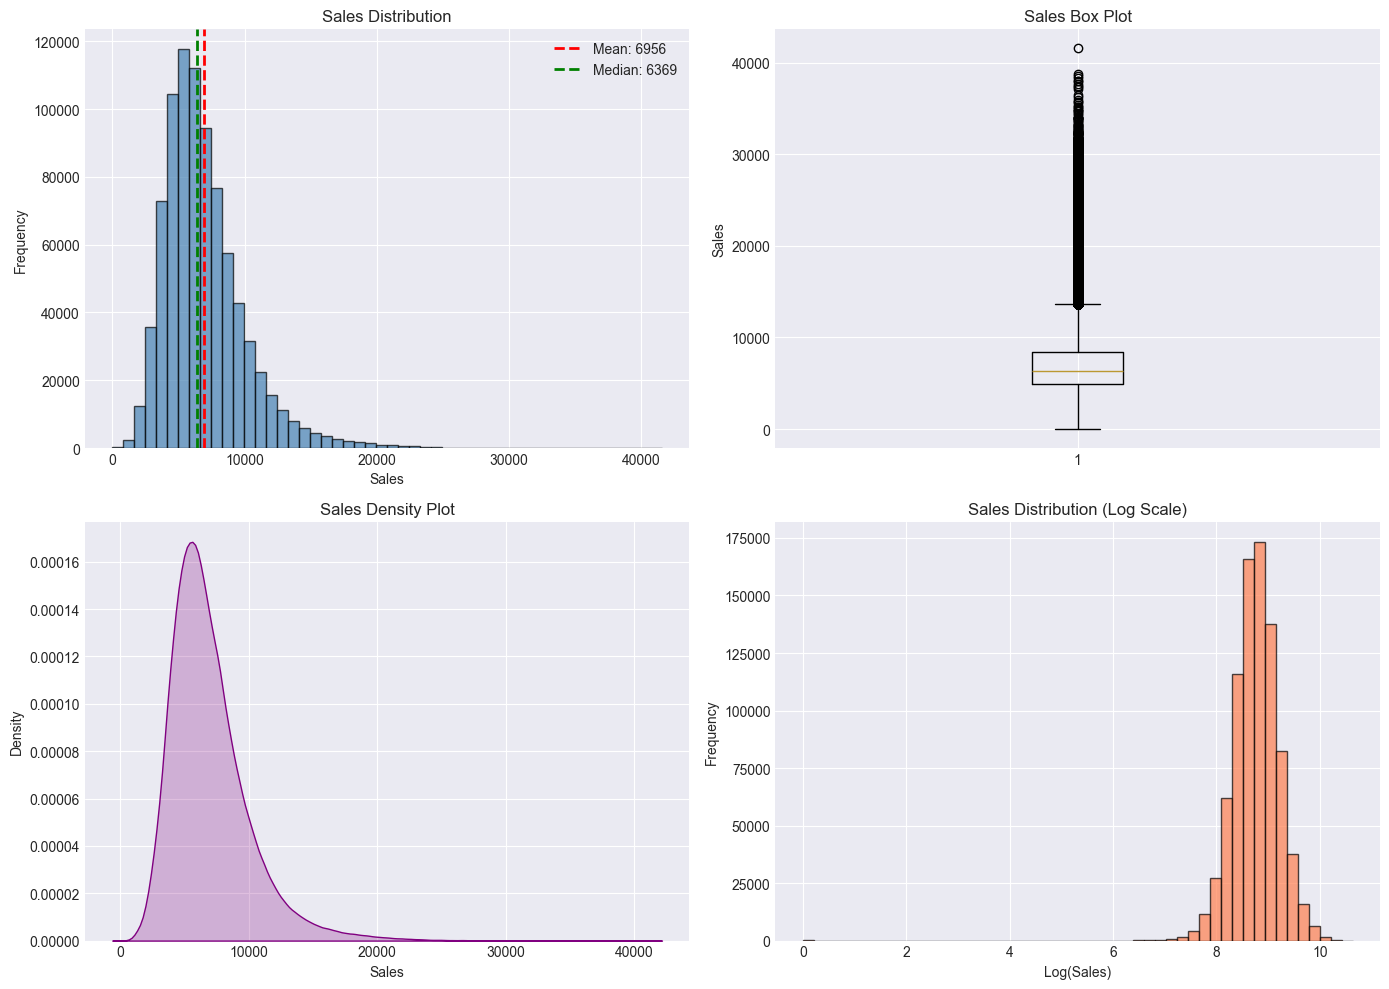


✓ Sales distribution plots saved to images/sales_distribution.png


In [4]:
# Cell 3: Analyze sales distribution
print("="*80)
print("SALES DISTRIBUTION ANALYSIS")
print("="*80)

# Sales statistics
print(f"\nSales Statistics:")
print(f"  Mean:     {df['Sales'].mean():,.0f}")
print(f"  Median:   {df['Sales'].median():,.0f}")
print(f"  Std Dev:  {df['Sales'].std():,.0f}")
print(f"  Min:      {df['Sales'].min():,.0f}")
print(f"  Max:      {df['Sales'].max():,.0f}")

# Create visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histogram
axes[0, 0].hist(df['Sales'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0, 0].axvline(df['Sales'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df["Sales"].mean():.0f}')
axes[0, 0].axvline(df['Sales'].median(), color='green', linestyle='--', linewidth=2, label=f'Median: {df["Sales"].median():.0f}')
axes[0, 0].set_xlabel('Sales')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Sales Distribution')
axes[0, 0].legend()

# Box plot
axes[0, 1].boxplot(df['Sales'], vert=True)
axes[0, 1].set_ylabel('Sales')
axes[0, 1].set_title('Sales Box Plot')

# KDE plot
sns.kdeplot(data=df, x='Sales', fill=True, ax=axes[1, 0], color='purple')
axes[1, 0].set_title('Sales Density Plot')
axes[1, 0].set_xlabel('Sales')

# Log scale histogram
axes[1, 1].hist(np.log1p(df['Sales']), bins=50, edgecolor='black', alpha=0.7, color='coral')
axes[1, 1].set_xlabel('Log(Sales)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Sales Distribution (Log Scale)')

plt.tight_layout()
plt.savefig('../images/sales_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

print("\n✓ Sales distribution plots saved to images/sales_distribution.png")

TIME SERIES ANALYSIS

Daily Sales Statistics:
  Average daily total sales: 6,234,799
  Max daily total sales: 15,623,548
  Min daily total sales: 97,235


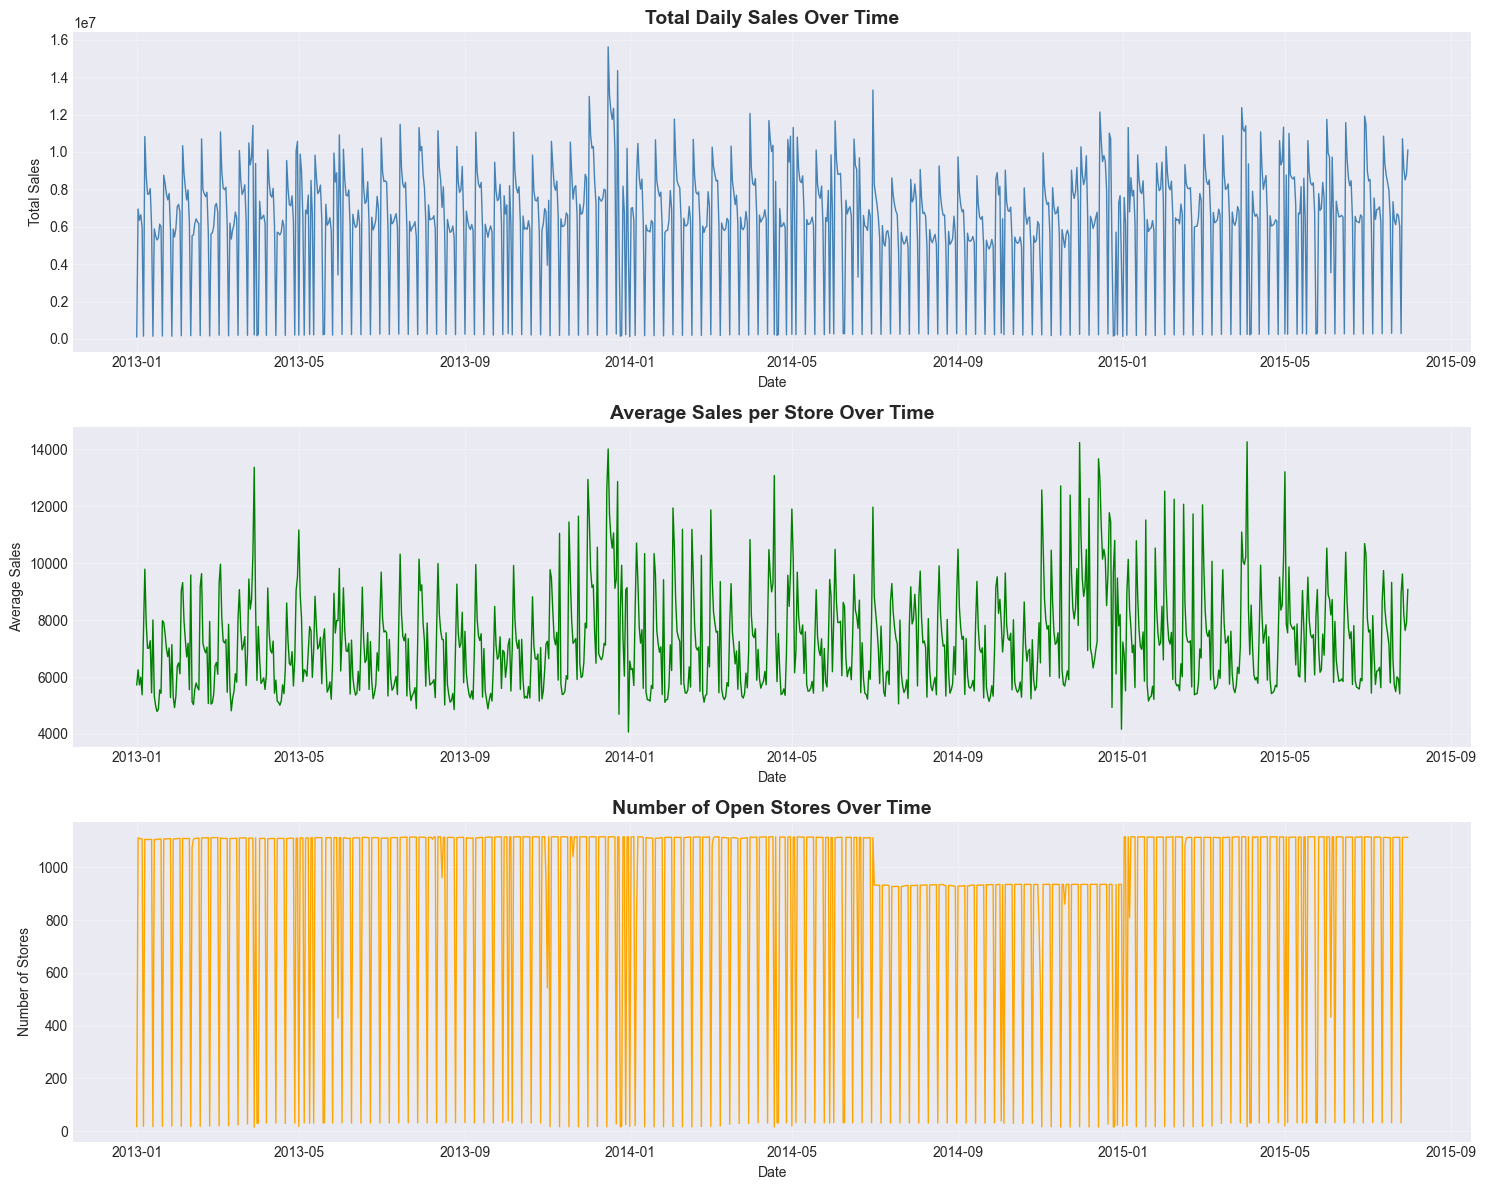


✓ Time series plots saved to images/time_series_analysis.png


In [5]:
# Cell 4: Analyze sales over time
print("="*80)
print("TIME SERIES ANALYSIS")
print("="*80)

# Aggregate daily sales
daily_sales = df.groupby('Date')['Sales'].agg(['sum', 'mean', 'count']).reset_index()
daily_sales.columns = ['Date', 'Total_Sales', 'Avg_Sales', 'Num_Stores']

print(f"\nDaily Sales Statistics:")
print(f"  Average daily total sales: {daily_sales['Total_Sales'].mean():,.0f}")
print(f"  Max daily total sales: {daily_sales['Total_Sales'].max():,.0f}")
print(f"  Min daily total sales: {daily_sales['Total_Sales'].min():,.0f}")

# Create time series plots
fig, axes = plt.subplots(3, 1, figsize=(15, 12))

# Total sales over time
axes[0].plot(daily_sales['Date'], daily_sales['Total_Sales'], linewidth=1, color='steelblue')
axes[0].set_title('Total Daily Sales Over Time', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Total Sales')
axes[0].grid(True, alpha=0.3)

# Average sales per store over time
axes[1].plot(daily_sales['Date'], daily_sales['Avg_Sales'], linewidth=1, color='green')
axes[1].set_title('Average Sales per Store Over Time', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Average Sales')
axes[1].grid(True, alpha=0.3)

# Number of open stores over time
axes[2].plot(daily_sales['Date'], daily_sales['Num_Stores'], linewidth=1, color='orange')
axes[2].set_title('Number of Open Stores Over Time', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Date')
axes[2].set_ylabel('Number of Stores')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../images/time_series_analysis.png', dpi=100, bbox_inches='tight')
plt.show()

print("\n✓ Time series plots saved to images/time_series_analysis.png")

SEASONAL PATTERNS


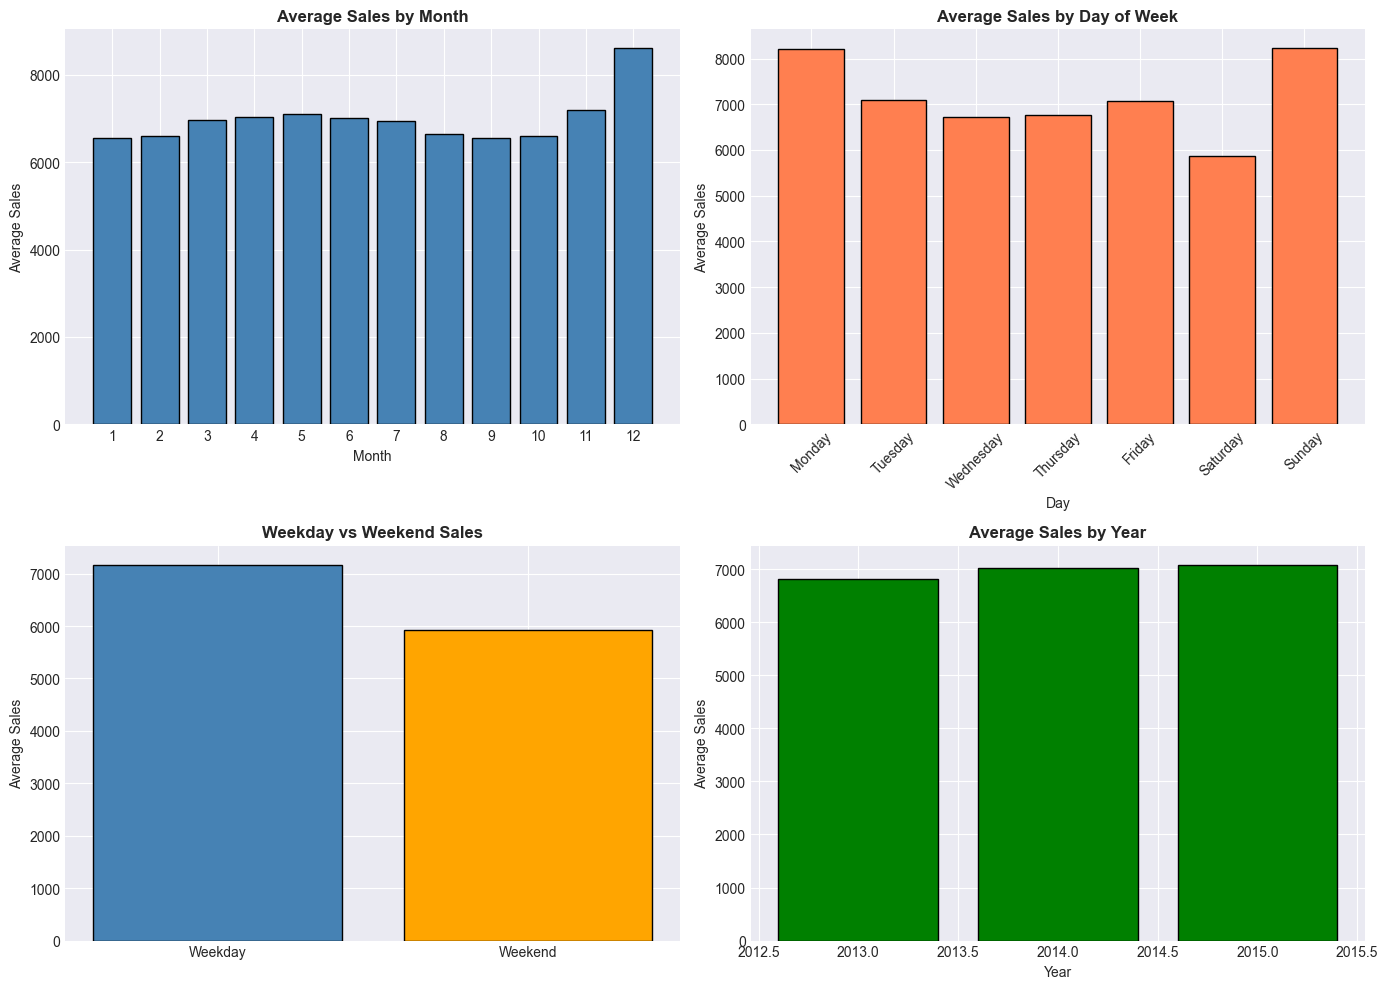


📊 Seasonal Insights:
  • Best month for sales: 12 (Avg: 8,609)
  • Worst month for sales: 9 (Avg: 6,546)
  • Best day: Sunday
  • Weekend sales vs Weekday: 82.7%


In [7]:
# Cell 5: Analyze seasonal patterns
print("="*80)
print("SEASONAL PATTERNS")
print("="*80)

# Create figure
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Monthly pattern
monthly_sales = df.groupby('Month')['Sales'].mean().reset_index()
axes[0, 0].bar(monthly_sales['Month'], monthly_sales['Sales'], color='steelblue', edgecolor='black')
axes[0, 0].set_title('Average Sales by Month', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Month')
axes[0, 0].set_ylabel('Average Sales')
axes[0, 0].set_xticks(range(1, 13))

# Day of week pattern
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_sales = df.groupby('DayOfWeek')['Sales'].mean().reset_index()
dow_sales['DayName'] = dow_order
axes[0, 1].bar(dow_sales['DayName'], dow_sales['Sales'], color='coral', edgecolor='black')
axes[0, 1].set_title('Average Sales by Day of Week', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Day')
axes[0, 1].set_ylabel('Average Sales')
axes[0, 1].tick_params(axis='x', rotation=45)

# Weekend vs Weekday
df['IsWeekend'] = df['DayOfWeek'].isin([5, 6])  # Saturday=5, Sunday=6
weekend_comparison = df.groupby('IsWeekend')['Sales'].mean()
axes[1, 0].bar(['Weekday', 'Weekend'], weekend_comparison.values, color=['steelblue', 'orange'], edgecolor='black')
axes[1, 0].set_title('Weekday vs Weekend Sales', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Average Sales')

# Yearly trend
yearly_sales = df.groupby('Year')['Sales'].mean().reset_index()
axes[1, 1].bar(yearly_sales['Year'], yearly_sales['Sales'], color='green', edgecolor='black')
axes[1, 1].set_title('Average Sales by Year', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Year')
axes[1, 1].set_ylabel('Average Sales')

plt.tight_layout()
plt.savefig('../images/seasonal_patterns.png', dpi=100, bbox_inches='tight')
plt.show()

# Print insights
print("\n📊 Seasonal Insights:")
print(f"  • Best month for sales: {monthly_sales.loc[monthly_sales['Sales'].idxmax(), 'Month']} (Avg: {monthly_sales['Sales'].max():,.0f})")
print(f"  • Worst month for sales: {monthly_sales.loc[monthly_sales['Sales'].idxmin(), 'Month']} (Avg: {monthly_sales['Sales'].min():,.0f})")
print(f"  • Best day: {dow_sales.loc[dow_sales['Sales'].idxmax(), 'DayName']}")
print(f"  • Weekend sales vs Weekday: {weekend_comparison[True]/weekend_comparison[False]*100:.1f}%")

PROMOTION ANALYSIS

Promo Impact:
          Avg_Sales  Avg_Customers
No Promo    5929.41         696.86
Promo       8228.28         844.43

📈 Lift from Promotions:
  • Sales lift: 38.8%
  • Customers lift: 21.2%


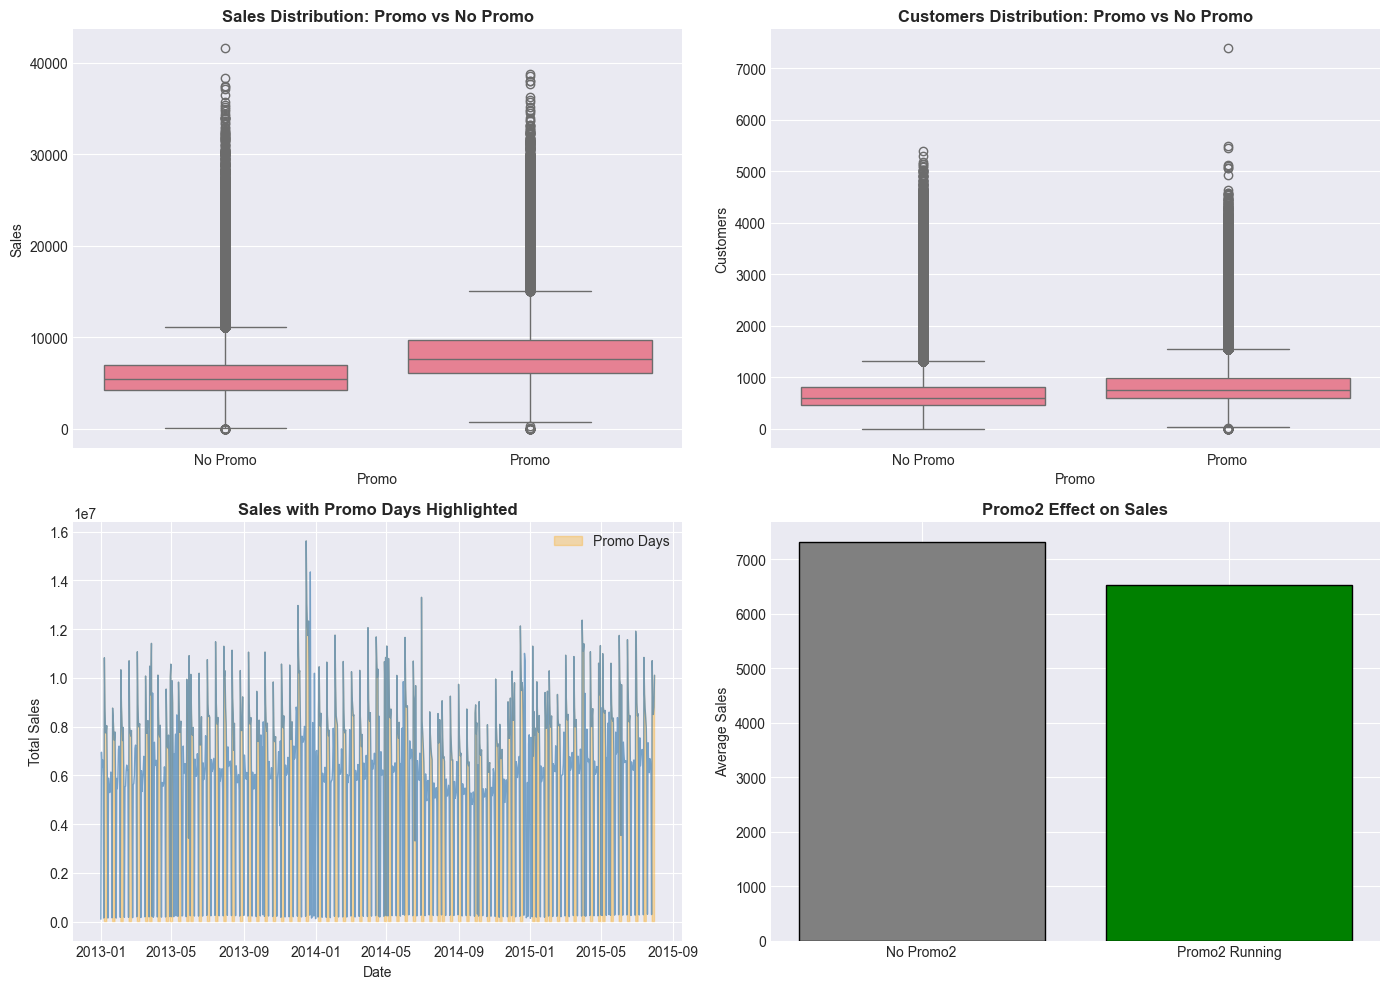


✓ Promo analysis plots saved to images/promo_analysis.png


In [9]:
# Cell 6: Analyze promotion effectiveness
print("="*80)
print("PROMOTION ANALYSIS")
print("="*80)

# Compare promo vs no promo
promo_comparison = df.groupby('Promo')[['Sales', 'Customers']].mean()
promo_comparison.columns = ['Avg_Sales', 'Avg_Customers']
promo_comparison.index = ['No Promo', 'Promo']

print("\nPromo Impact:")
print(promo_comparison)

# Sales lift from promo
sales_lift = (promo_comparison.loc['Promo', 'Avg_Sales'] / promo_comparison.loc['No Promo', 'Avg_Sales'] - 1) * 100
customers_lift = (promo_comparison.loc['Promo', 'Avg_Customers'] / promo_comparison.loc['No Promo', 'Avg_Customers'] - 1) * 100

print(f"\n📈 Lift from Promotions:")
print(f"  • Sales lift: {sales_lift:.1f}%")
print(f"  • Customers lift: {customers_lift:.1f}%")

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Sales by promo
sns.boxplot(data=df, x='Promo', y='Sales', ax=axes[0, 0])
axes[0, 0].set_title('Sales Distribution: Promo vs No Promo', fontsize=12, fontweight='bold')
axes[0, 0].set_xticklabels(['No Promo', 'Promo'])

# Customers by promo
sns.boxplot(data=df, x='Promo', y='Customers', ax=axes[0, 1])
axes[0, 1].set_title('Customers Distribution: Promo vs No Promo', fontsize=12, fontweight='bold')
axes[0, 1].set_xticklabels(['No Promo', 'Promo'])

# Sales over time with promo highlight
daily_promo = df.groupby('Date')['Promo'].mean().reset_index()
daily_sales_promo = df.groupby('Date')['Sales'].sum().reset_index()
daily_merged = daily_sales_promo.merge(daily_promo, on='Date')

axes[1, 0].fill_between(daily_merged['Date'], 0, daily_merged['Sales'], 
                         where=daily_merged['Promo'] > 0.5, color='orange', alpha=0.3, label='Promo Days')
axes[1, 0].plot(daily_merged['Date'], daily_merged['Sales'], color='steelblue', linewidth=1, alpha=0.7)
axes[1, 0].set_title('Sales with Promo Days Highlighted', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Date')
axes[1, 0].set_ylabel('Total Sales')
axes[1, 0].legend()

# Promo2 effect
promo2_effect = df.groupby('IsPromo2Running')['Sales'].mean()
axes[1, 1].bar(['No Promo2', 'Promo2 Running'], promo2_effect.values, color=['gray', 'green'], edgecolor='black')
axes[1, 1].set_title('Promo2 Effect on Sales', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Average Sales')

plt.tight_layout()
plt.savefig('../images/promo_analysis.png', dpi=100, bbox_inches='tight')
plt.show()

print("\n✓ Promo analysis plots saved to images/promo_analysis.png")

STORE TYPE ANALYSIS

Store Type Performance:
                  Avg_Sales  Median_Sales  Std_Sales  Avg_Customers  \
StoreType_Letter                                                      
a                   6925.17       6285.00    3277.79         795.36   
b                  10231.41       9130.00    5157.19        2021.82   
c                   6932.51       6407.00    2897.56         815.47   
d                   6822.14       6395.00    2556.58         606.34   

                  Sales_Per_Customer  
StoreType_Letter                      
a                               8.85  
b                               5.13  
c                               8.63  
d                              11.28  


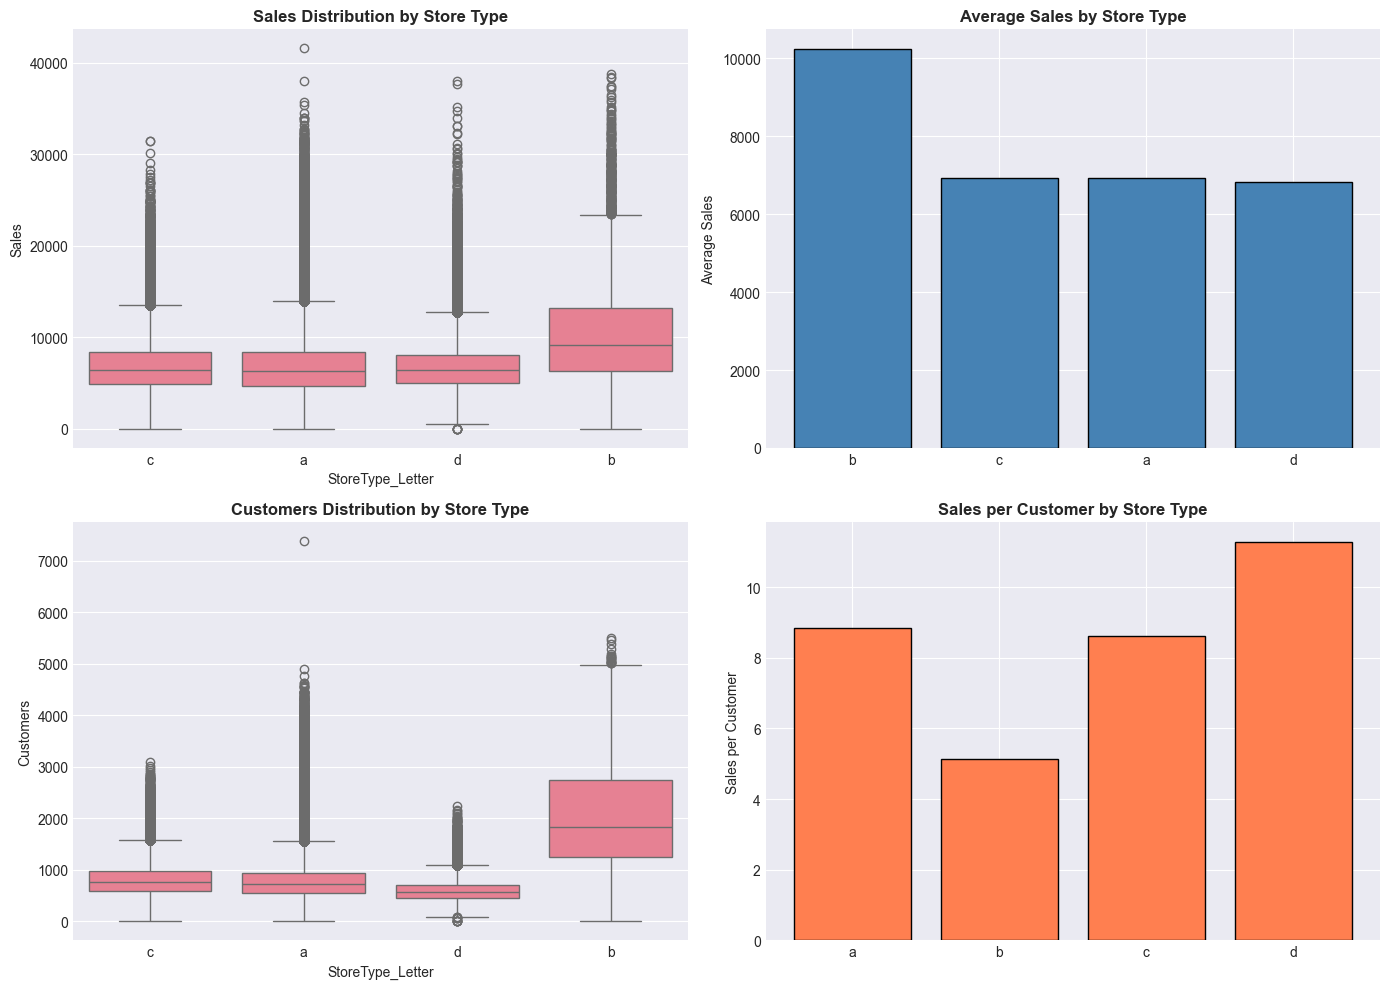


✓ Store type analysis saved to images/store_type_analysis.png


In [10]:
# Cell 7: Analyze different store types
print("="*80)
print("STORE TYPE ANALYSIS")
print("="*80)

# Map store type codes back to letters
store_type_map = {0: 'a', 1: 'b', 2: 'c', 3: 'd'}
df['StoreType_Letter'] = df['StoreType_Code'].map(store_type_map)

# Store type performance
store_performance = df.groupby('StoreType_Letter').agg({
    'Sales': ['mean', 'median', 'std'],
    'Customers': 'mean',
    'SalesPerCustomer': 'mean'
}).round(2)

store_performance.columns = ['Avg_Sales', 'Median_Sales', 'Std_Sales', 'Avg_Customers', 'Sales_Per_Customer']
print("\nStore Type Performance:")
print(store_performance)

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Sales by store type
sns.boxplot(data=df, x='StoreType_Letter', y='Sales', ax=axes[0, 0])
axes[0, 0].set_title('Sales Distribution by Store Type', fontsize=12, fontweight='bold')

# Average sales by store type
store_avg = df.groupby('StoreType_Letter')['Sales'].mean().sort_values(ascending=False)
axes[0, 1].bar(store_avg.index, store_avg.values, color='steelblue', edgecolor='black')
axes[0, 1].set_title('Average Sales by Store Type', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Average Sales')

# Customers by store type
sns.boxplot(data=df, x='StoreType_Letter', y='Customers', ax=axes[1, 0])
axes[1, 0].set_title('Customers Distribution by Store Type', fontsize=12, fontweight='bold')

# Sales per customer by store type
spc_by_type = df.groupby('StoreType_Letter')['SalesPerCustomer'].mean()
axes[1, 1].bar(spc_by_type.index, spc_by_type.values, color='coral', edgecolor='black')
axes[1, 1].set_title('Sales per Customer by Store Type', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Sales per Customer')

plt.tight_layout()
plt.savefig('../images/store_type_analysis.png', dpi=100, bbox_inches='tight')
plt.show()

print("\n✓ Store type analysis saved to images/store_type_analysis.png")

COMPETITION ANALYSIS

Competition Distance Effect on Sales:
                         mean   count
CompDistance_Category                
Very Close (<500m)    7609.90  168108
Close (500-2000m)     6919.90  212693
Medium (2-5km)        6665.03  199069
Far (5-10km)          6742.59  121911
Very Far (>10km)      6824.76  142611

Competition Age Effect on Sales:
CompAge_Category
No Competition   6991.40
<1 Year          7111.16
1-2 Years        7138.56
2-3 Years        6950.66
>3 Years         6862.01
Name: Sales, dtype: float64


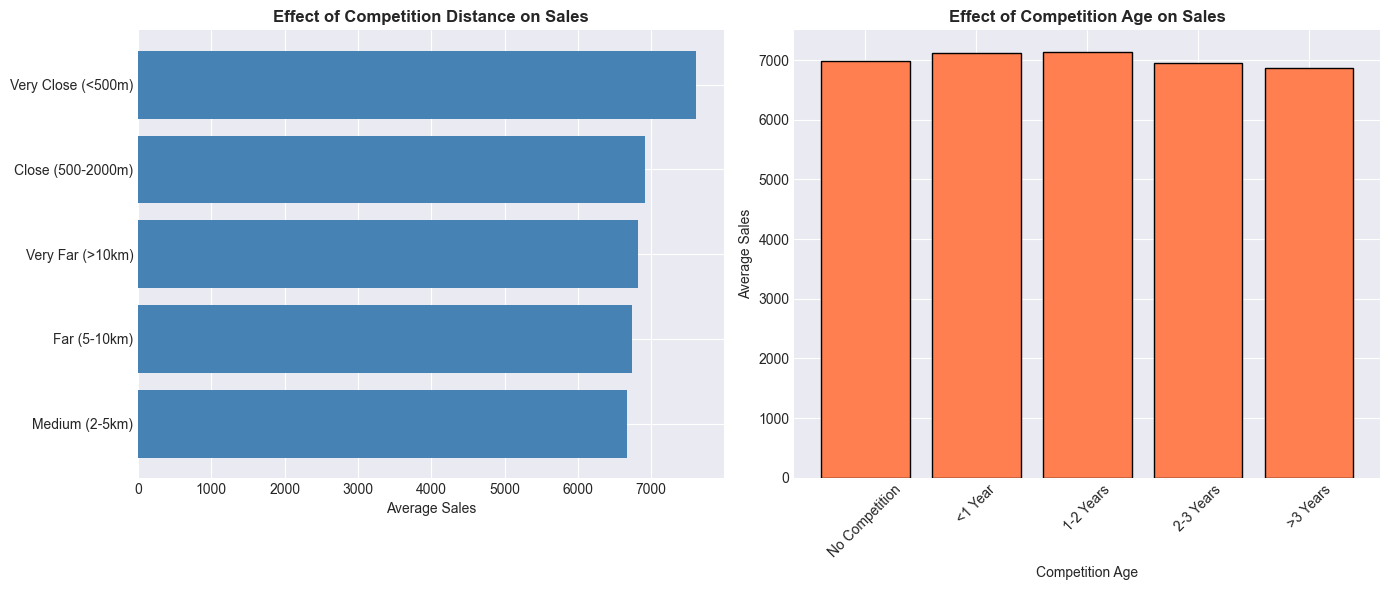


✓ Competition analysis saved to images/competition_analysis.png


In [11]:
# Cell 8: Analyze competition effect on sales
print("="*80)
print("COMPETITION ANALYSIS")
print("="*80)

# Create competition distance categories
df['CompDistance_Category'] = pd.cut(df['CompetitionDistance'], 
                                      bins=[0, 500, 2000, 5000, 10000, float('inf')],
                                      labels=['Very Close (<500m)', 'Close (500-2000m)', 
                                              'Medium (2-5km)', 'Far (5-10km)', 'Very Far (>10km)'])

# Competition effect
comp_effect = df.groupby('CompDistance_Category')['Sales'].agg(['mean', 'count']).round(2)
print("\nCompetition Distance Effect on Sales:")
print(comp_effect)

# Days since competition opened
df['CompAge_Category'] = pd.cut(df['DaysSinceCompetitionOpen'],
                                 bins=[-1, 0, 365, 730, 1095, float('inf')],
                                 labels=['No Competition', '<1 Year', '1-2 Years', '2-3 Years', '>3 Years'])

comp_age_effect = df.groupby('CompAge_Category')['Sales'].mean().round(2)
print("\nCompetition Age Effect on Sales:")
print(comp_age_effect)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Competition distance effect
comp_effect_sorted = comp_effect.sort_values('mean')
axes[0].barh(comp_effect_sorted.index, comp_effect_sorted['mean'], color='steelblue')
axes[0].set_title('Effect of Competition Distance on Sales', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Average Sales')

# Competition age effect
axes[1].bar(comp_age_effect.index, comp_age_effect.values, color='coral', edgecolor='black')
axes[1].set_title('Effect of Competition Age on Sales', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Competition Age')
axes[1].set_ylabel('Average Sales')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../images/competition_analysis.png', dpi=100, bbox_inches='tight')
plt.show()

print("\n✓ Competition analysis saved to images/competition_analysis.png")

CORRELATION ANALYSIS

Features most correlated with Sales:
Sales                       1.00
Customers                   0.82
Promo                       0.37
Assortment_Code             0.11
Month                       0.07
SchoolHoliday               0.04
Year                        0.04
Holiday_a                   0.01
Holiday_b                   0.01
Holiday_c                   0.01
DaysSinceCompetitionOpen   -0.00
StoreType_Code             -0.02
Holiday_0                  -0.02
CompetitionDistance        -0.04
Promo2                     -0.13
IsPromo2Running            -0.13
DayOfWeek                  -0.18
Name: Sales, dtype: float64


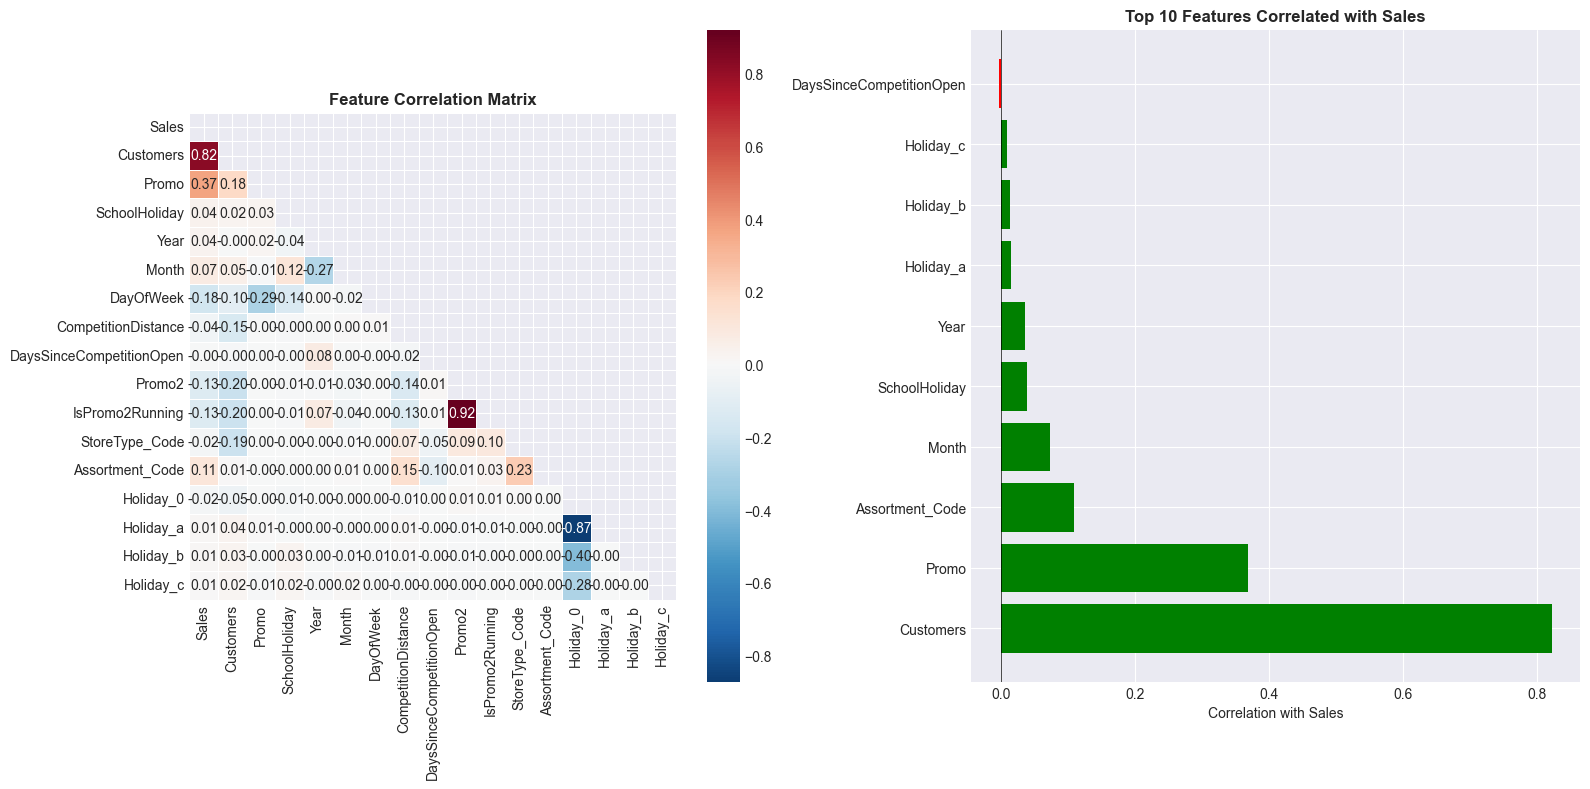


✓ Correlation analysis saved to images/correlation_analysis.png


In [12]:
# Cell 9: Correlation between features
print("="*80)
print("CORRELATION ANALYSIS")
print("="*80)

# Select numeric columns for correlation
numeric_cols = ['Sales', 'Customers', 'Promo', 'SchoolHoliday', 'Year', 'Month', 
                'DayOfWeek', 'CompetitionDistance', 'DaysSinceCompetitionOpen', 
                'Promo2', 'IsPromo2Running', 'StoreType_Code', 'Assortment_Code']

# Add holiday columns
holiday_cols = [col for col in df.columns if col.startswith('Holiday_')]
numeric_cols.extend(holiday_cols)

# Calculate correlation matrix
corr_matrix = df[numeric_cols].corr()

# Get correlation with Sales
sales_corr = corr_matrix['Sales'].sort_values(ascending=False)
print("\nFeatures most correlated with Sales:")
print(sales_corr)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Correlation heatmap
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', 
            center=0, square=True, linewidths=0.5, ax=axes[0])
axes[0].set_title('Feature Correlation Matrix', fontsize=12, fontweight='bold')

# Sales correlation bar plot
sales_corr_df = sales_corr.drop('Sales').head(10)
colors = ['green' if x > 0 else 'red' for x in sales_corr_df.values]
axes[1].barh(range(len(sales_corr_df)), sales_corr_df.values, color=colors)
axes[1].set_yticks(range(len(sales_corr_df)))
axes[1].set_yticklabels(sales_corr_df.index)
axes[1].set_title('Top 10 Features Correlated with Sales', fontsize=12, fontweight='bold')
axes[1].axvline(x=0, color='black', linestyle='-', linewidth=0.5)
axes[1].set_xlabel('Correlation with Sales')

plt.tight_layout()
plt.savefig('../images/correlation_analysis.png', dpi=100, bbox_inches='tight')
plt.show()

print("\n✓ Correlation analysis saved to images/correlation_analysis.png")

ASSORTMENT ANALYSIS

Assortment Type Performance:
                 Avg_Sales  Median_Sales  Std_Sales  Avg_Customers  \
Assortment_Type                                                      
Basic              6621.02       6082.00    2972.50         747.94   
Extended           7300.53       6675.00    3184.14         752.17   
Extra              8639.35       8081.00    3806.01        2066.80   

                 Promo_Frequency  
Assortment_Type                   
Basic                       0.45  
Extended                    0.45  
Extra                       0.38  


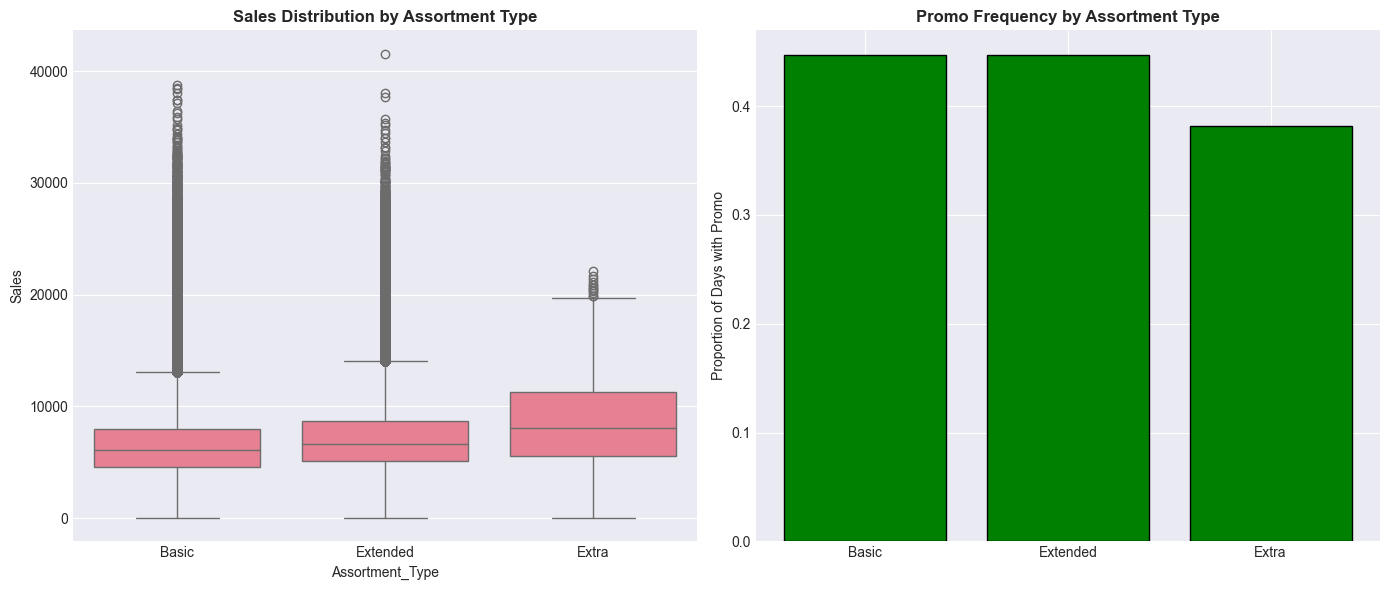


✓ Assortment analysis saved to images/assortment_analysis.png


In [13]:
# Cell 10: Analyze assortment types
print("="*80)
print("ASSORTMENT ANALYSIS")
print("="*80)

# Map assortment codes
assortment_map = {0: 'Basic', 1: 'Extra', 2: 'Extended'}
df['Assortment_Type'] = df['Assortment_Code'].map(assortment_map)

# Assortment performance
assortment_perf = df.groupby('Assortment_Type').agg({
    'Sales': ['mean', 'median', 'std'],
    'Customers': 'mean',
    'Promo': 'mean'
}).round(2)

assortment_perf.columns = ['Avg_Sales', 'Median_Sales', 'Std_Sales', 'Avg_Customers', 'Promo_Frequency']
print("\nAssortment Type Performance:")
print(assortment_perf)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Sales by assortment
sns.boxplot(data=df, x='Assortment_Type', y='Sales', ax=axes[0])
axes[0].set_title('Sales Distribution by Assortment Type', fontsize=12, fontweight='bold')

# Promo frequency by assortment
promo_by_assortment = df.groupby('Assortment_Type')['Promo'].mean()
axes[1].bar(promo_by_assortment.index, promo_by_assortment.values, color='green', edgecolor='black')
axes[1].set_title('Promo Frequency by Assortment Type', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Proportion of Days with Promo')

plt.tight_layout()
plt.savefig('../images/assortment_analysis.png', dpi=100, bbox_inches='tight')
plt.show()

print("\n✓ Assortment analysis saved to images/assortment_analysis.png")

HOLIDAY ANALYSIS

Holiday Effect on Sales:
            Holiday_Sales  Normal_Sales  Sales_Change_%
No Holiday        6953.52       8808.63          -21.06
a                 8487.47       6954.25           22.05
b                 9887.89       6955.01           42.17
c                 9743.75       6955.28           40.09


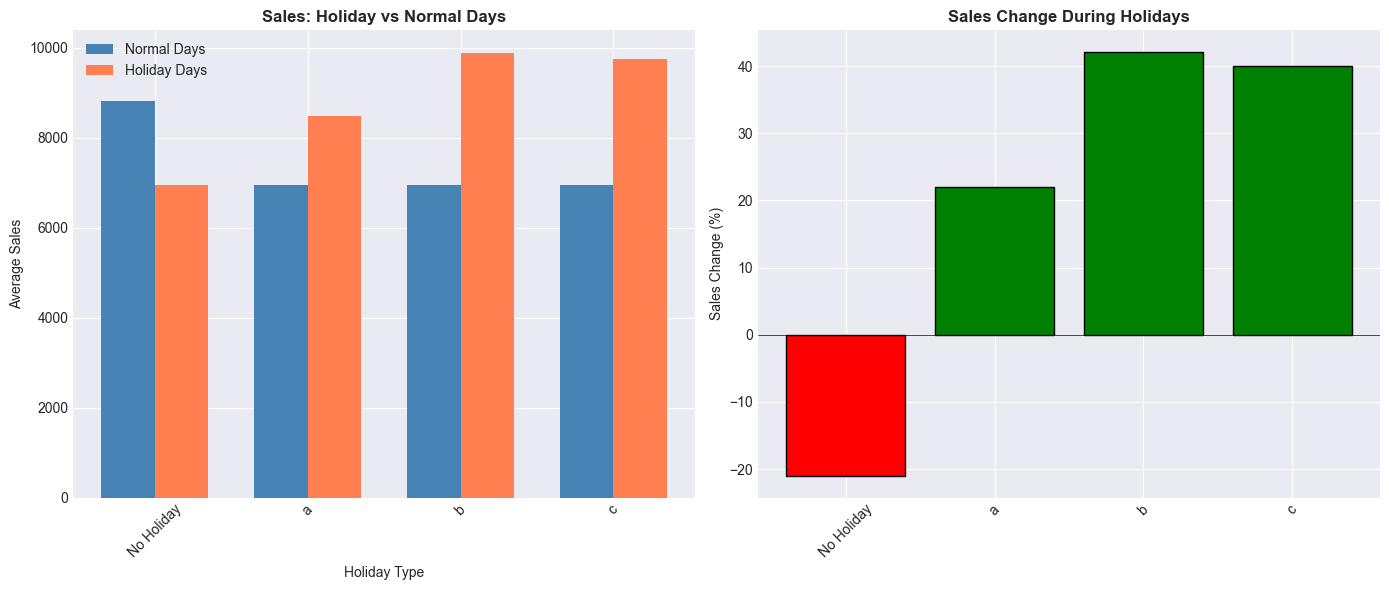


✓ Holiday analysis saved to images/holiday_analysis.png


In [14]:
# Cell 11: Analyze holiday effects
print("="*80)
print("HOLIDAY ANALYSIS")
print("="*80)

# Get holiday columns
holiday_cols = [col for col in df.columns if col.startswith('Holiday_')]
holiday_names = [col.replace('Holiday_', '') for col in holiday_cols]

# Holiday effect on sales
holiday_effect = {}
for col, name in zip(holiday_cols, holiday_names):
    if name == '0':
        name = 'No Holiday'
    holiday_sales = df[df[col] == 1]['Sales'].mean() if len(df[df[col] == 1]) > 0 else 0
    normal_sales = df[df[col] == 0]['Sales'].mean()
    holiday_effect[name] = {
        'Holiday_Sales': holiday_sales,
        'Normal_Sales': normal_sales,
        'Sales_Change_%': ((holiday_sales / normal_sales) - 1) * 100 if normal_sales > 0 else 0
    }

holiday_df = pd.DataFrame(holiday_effect).T
print("\nHoliday Effect on Sales:")
print(holiday_df)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Holiday vs normal sales comparison
x = np.arange(len(holiday_df))
width = 0.35

axes[0].bar(x - width/2, holiday_df['Normal_Sales'], width, label='Normal Days', color='steelblue')
axes[0].bar(x + width/2, holiday_df['Holiday_Sales'], width, label='Holiday Days', color='coral')
axes[0].set_xlabel('Holiday Type')
axes[0].set_ylabel('Average Sales')
axes[0].set_title('Sales: Holiday vs Normal Days', fontsize=12, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(holiday_df.index, rotation=45)
axes[0].legend()

# Percentage change during holidays
colors = ['green' if x > 0 else 'red' for x in holiday_df['Sales_Change_%']]
axes[1].bar(holiday_df.index, holiday_df['Sales_Change_%'], color=colors, edgecolor='black')
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[1].set_ylabel('Sales Change (%)')
axes[1].set_title('Sales Change During Holidays', fontsize=12, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../images/holiday_analysis.png', dpi=100, bbox_inches='tight')
plt.show()

print("\n✓ Holiday analysis saved to images/holiday_analysis.png")

STORE PERFORMANCE ANALYSIS

Top 10 Stores by Average Sales:
       Avg_Sales  Total_Sales  Std_Sales  Avg_Customers  Sales_Per_Customer  \
Store                                                                         
817     21757.48     17057867    4674.80        3130.57                6.94   
262     20718.52     19516842    4668.88        3402.01                6.06   
1114    20666.56     16202585    3452.94        3200.95                6.45   
251     19123.07     14896870    3547.64        2450.49                7.77   
842     18574.80     11553523    3788.99        1149.24               16.06   
513     18179.09     14252406    3284.60        2096.34                8.63   
562     17969.56     16927322    2931.93        3105.05                5.76   
788     17961.91     14082141    3150.65        1717.90               10.44   
383     17294.72     13489879    2785.81        2205.45                7.81   
756     16574.82     12911782    3912.56        2346.57                

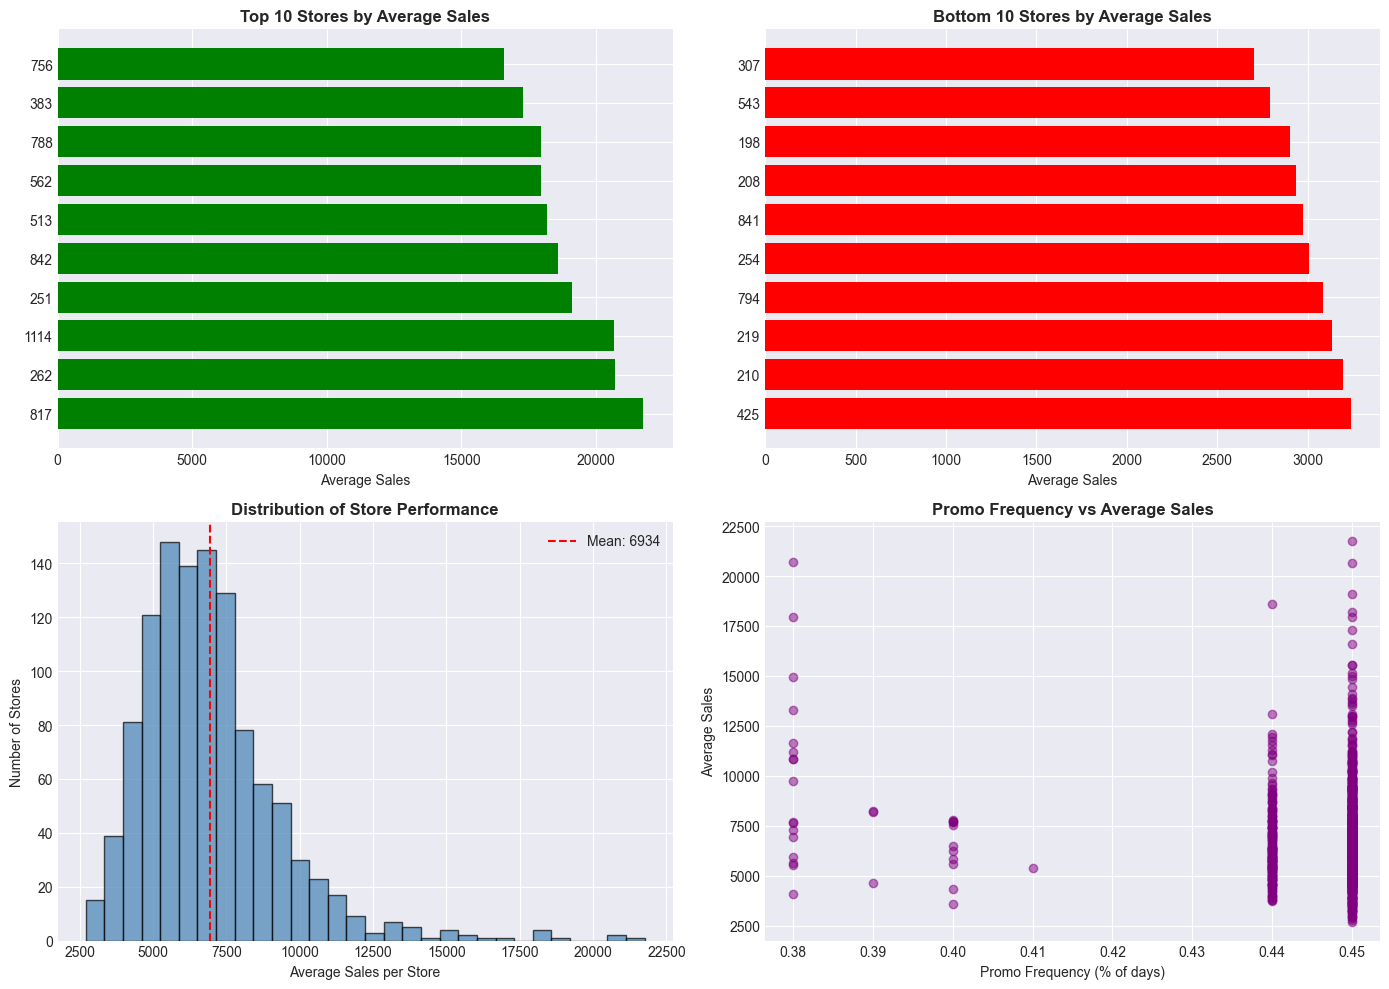


✓ Store performance analysis saved to images/store_performance.png


In [15]:
# Cell 12: Identify top and bottom performing stores
print("="*80)
print("STORE PERFORMANCE ANALYSIS")
print("="*80)

# Store performance metrics
store_performance = df.groupby('Store').agg({
    'Sales': ['mean', 'sum', 'std'],
    'Customers': 'mean',
    'SalesPerCustomer': 'mean',
    'Promo': 'mean'
}).round(2)

store_performance.columns = ['Avg_Sales', 'Total_Sales', 'Std_Sales', 'Avg_Customers', 'Sales_Per_Customer', 'Promo_Frequency']
store_performance = store_performance.sort_values('Avg_Sales', ascending=False)

print("\nTop 10 Stores by Average Sales:")
print(store_performance.head(10))

print("\nBottom 10 Stores by Average Sales:")
print(store_performance.tail(10))

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Top 10 stores
top_stores = store_performance.head(10)
axes[0, 0].barh(range(len(top_stores)), top_stores['Avg_Sales'].values, color='green')
axes[0, 0].set_yticks(range(len(top_stores)))
axes[0, 0].set_yticklabels(top_stores.index)
axes[0, 0].set_title('Top 10 Stores by Average Sales', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Average Sales')

# Bottom 10 stores
bottom_stores = store_performance.tail(10)
axes[0, 1].barh(range(len(bottom_stores)), bottom_stores['Avg_Sales'].values, color='red')
axes[0, 1].set_yticks(range(len(bottom_stores)))
axes[0, 1].set_yticklabels(bottom_stores.index)
axes[0, 1].set_title('Bottom 10 Stores by Average Sales', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Average Sales')

# Sales distribution across stores
axes[1, 0].hist(store_performance['Avg_Sales'], bins=30, edgecolor='black', alpha=0.7, color='steelblue')
axes[1, 0].axvline(store_performance['Avg_Sales'].mean(), color='red', linestyle='--', label=f'Mean: {store_performance["Avg_Sales"].mean():.0f}')
axes[1, 0].set_xlabel('Average Sales per Store')
axes[1, 0].set_ylabel('Number of Stores')
axes[1, 0].set_title('Distribution of Store Performance', fontsize=12, fontweight='bold')
axes[1, 0].legend()

# Promo frequency vs Sales
axes[1, 1].scatter(store_performance['Promo_Frequency'], store_performance['Avg_Sales'], alpha=0.5, color='purple')
axes[1, 1].set_xlabel('Promo Frequency (% of days)')
axes[1, 1].set_ylabel('Average Sales')
axes[1, 1].set_title('Promo Frequency vs Average Sales', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('../images/store_performance.png', dpi=100, bbox_inches='tight')
plt.show()

print("\n✓ Store performance analysis saved to images/store_performance.png")

In [17]:
# Cell 13: Generate EDA summary report
print("="*80)
print("EXPLORATORY DATA ANALYSIS - SUMMARY REPORT")
print("="*80)

report = f"""
ROSSMANN SALES FORECASTING - EDA SUMMARY REPORT
================================================

1. SALES OVERVIEW
   • Total sales records: {len(df):,}
   • Date range: {df['Date'].min().date()} to {df['Date'].max().date()}
   • Average daily sales: {daily_sales['Total_Sales'].mean():,.0f}
   • Average sales per store: {df['Sales'].mean():,.0f}
   • Sales range: {df['Sales'].min():,.0f} to {df['Sales'].max():,.0f}

2. SEASONAL PATTERNS
   • Best month: {monthly_sales.loc[monthly_sales['Sales'].idxmax(), 'Month']} (Avg: {monthly_sales['Sales'].max():,.0f})
   • Best day: {dow_sales.loc[dow_sales['Sales'].idxmax(), 'DayName']}
   • Weekend sales are {weekend_comparison[True]/weekend_comparison[False]*100:.1f}% of weekday sales

3. PROMOTION IMPACT
   • Sales lift from promotions: {sales_lift:.1f}%
   • Customer lift from promotions: {customers_lift:.1f}%
   • Promo frequency: {df['Promo'].mean()*100:.1f}% of days

4. STORE INSIGHTS
   • Best store type: {store_performance['Avg_Sales'].idxmax()} (Avg: {store_performance['Avg_Sales'].max():,.0f})
   • Best assortment: {assortment_perf['Avg_Sales'].idxmax()}
   • Competition reduces sales by: {(1 - comp_effect.loc['Very Close (<500m)', 'mean'] / comp_effect.loc['Very Far (>10km)', 'mean'])*100:.1f}%

5. KEY CORRELATIONS
   • Strongest positive: Customers ({sales_corr['Customers']:.3f})
   • Strongest negative: Competition Distance ({sales_corr['CompetitionDistance']:.3f})

6. RECOMMENDATIONS FOR FORECASTING
   • Include promo as key feature
   • Account for day-of-week patterns
   • Consider store type in model
   • Include competition distance
   • Handle holiday effects separately

VISUALIZATIONS GENERATED:
   • sales_distribution.png
   • time_series_analysis.png
   • seasonal_patterns.png
   • promo_analysis.png
   • store_type_analysis.png
   • competition_analysis.png
   • correlation_analysis.png
   • assortment_analysis.png
   • holiday_analysis.png
   • store_performance.png
"""

print(report)

# Save report
report_path = Path('../reports/eda_summary_report.txt')
with open(report_path, 'w') as f:
    f.write(report)
print(f"✓ EDA report saved to: {report_path}")

EXPLORATORY DATA ANALYSIS - SUMMARY REPORT

ROSSMANN SALES FORECASTING - EDA SUMMARY REPORT

1. SALES OVERVIEW
   • Total sales records: 844,392
   • Date range: 2013-01-01 to 2015-07-31
   • Average daily sales: 6,234,799
   • Average sales per store: 6,956
   • Sales range: 0 to 41,551

2. SEASONAL PATTERNS
   • Best month: 12 (Avg: 8,609)
   • Best day: Sunday
   • Weekend sales are 82.7% of weekday sales

3. PROMOTION IMPACT
   • Sales lift from promotions: 38.8%
   • Customer lift from promotions: 21.2%
   • Promo frequency: 44.6% of days

4. STORE INSIGHTS
   • Best store type: 817 (Avg: 21,757)
   • Best assortment: Extra
   • Competition reduces sales by: -11.5%

5. KEY CORRELATIONS
   • Strongest positive: Customers (0.824)
   • Strongest negative: Competition Distance (-0.036)

6. RECOMMENDATIONS FOR FORECASTING
   • Include promo as key feature
   • Account for day-of-week patterns
   • Consider store type in model
   • Include competition distance
   • Handle holiday effect

In [18]:
# Cell 14: Save prepared data for modeling
print("="*80)
print("SAVING DATA FOR MODELING")
print("="*80)

# We'll use the same df_final from cleaning
# Add some engineered features we created in EDA
df['Promo_Flag'] = df['Promo']
df['Weekend_Flag'] = df['IsWeekend']

# Select final features for modeling
model_features = [
    'Store', 'Date', 'Sales', 'Customers',
    'Promo', 'SchoolHoliday', 'Weekend_Flag',
    'Year', 'Month', 'DayOfWeek', 'WeekOfYear',
    'CompetitionDistance', 'DaysSinceCompetitionOpen',
    'Promo2', 'IsPromo2Running', 'SalesPerCustomer',
    'StoreType_Code', 'Assortment_Code'
]

# Add holiday columns
holiday_cols = [col for col in df.columns if col.startswith('Holiday_')]
model_features.extend(holiday_cols)

# Create modeling dataset
model_df = df[model_features].copy()

# Save
model_path = Path('../data/processed/rossmann_model_ready.csv')
model_df.to_csv(model_path, index=False)

print(f"✓ Model-ready data saved to: {model_path}")
print(f"✓ Final shape: {model_df.shape[0]:,} rows, {model_df.shape[1]} columns")
print(f"✓ Features: {model_df.columns.tolist()}")

SAVING DATA FOR MODELING
✓ Model-ready data saved to: ..\data\processed\rossmann_model_ready.csv
✓ Final shape: 844,392 rows, 22 columns
✓ Features: ['Store', 'Date', 'Sales', 'Customers', 'Promo', 'SchoolHoliday', 'Weekend_Flag', 'Year', 'Month', 'DayOfWeek', 'WeekOfYear', 'CompetitionDistance', 'DaysSinceCompetitionOpen', 'Promo2', 'IsPromo2Running', 'SalesPerCustomer', 'StoreType_Code', 'Assortment_Code', 'Holiday_0', 'Holiday_a', 'Holiday_b', 'Holiday_c']
